# Class Notebook: AIML

## Flow for Today
1. Linear Regression basics on synthetic data
2. Underfitting and polynomial improvement
3. Sigmoid and Logistic Regression
4. Confusion matrix + stratified splitting
5. Threshold, precision-recall tradeoff, AUC
6. Mean vs median imputation with outliers

## Topic 1: Linear Regression

### Q1. How do we create a simple synthetic regression dataset?

   ad_spend      sales
0     10.00  31.973713
1     13.75  31.768886
2     17.50  42.931508
3     21.25  54.809239
4     25.00  45.626773


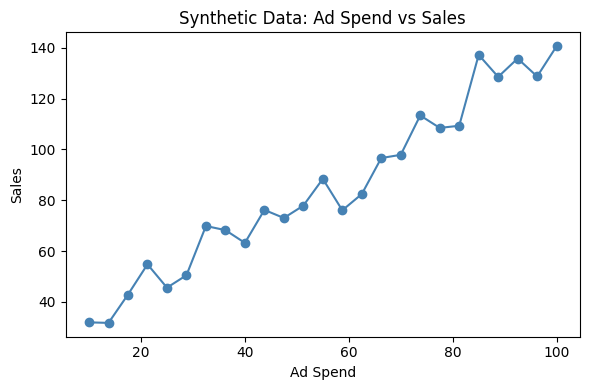

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)
x = np.linspace(10, 100, 25)
noise = np.random.normal(0, 8, size=len(x))
y = 1.3 * x + 15 + noise

df_reg = pd.DataFrame({"ad_spend": x, "sales": y})
print(df_reg.head())

plt.figure(figsize=(6, 4))
plt.plot(df_reg["ad_spend"], df_reg["sales"], "o-", color="steelblue")
plt.title("Synthetic Data: Ad Spend vs Sales")
plt.xlabel("Ad Spend")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

We generated synthetic data where sales generally increase with ad spend.
The main parameters were a linear trend ($1.3x + 15$) plus random noise.
The graph shows the data shape before any model is trained.

### Q2. How do we fit a basic linear regression model and check MSE?

Intercept: 19.96
Coefficient: 1.19
MSE: 46.71


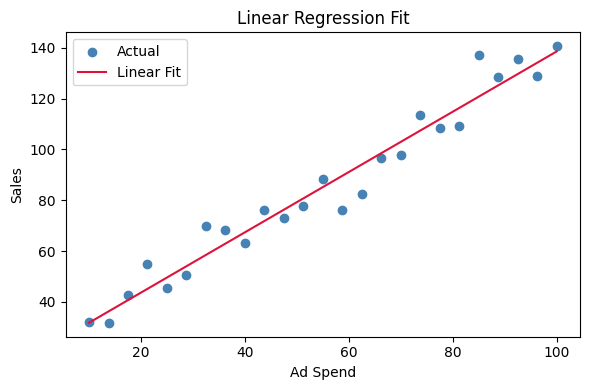

In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

X = df_reg[["ad_spend"]]
y = df_reg["sales"]

lin_model = LinearRegression()
lin_model.fit(X, y)
y_hat = lin_model.predict(X)
mse_lin = mean_squared_error(y, y_hat)

print("Intercept:", round(lin_model.intercept_, 2))
print("Coefficient:", round(lin_model.coef_[0], 2))
print("MSE:", round(mse_lin, 2))

plt.figure(figsize=(6, 4))
plt.scatter(df_reg["ad_spend"], y, color="steelblue", label="Actual")
plt.plot(df_reg["ad_spend"], y_hat, color="crimson", label="Linear Fit")
plt.title("Linear Regression Fit")
plt.xlabel("Ad Spend")
plt.ylabel("Sales")
plt.legend()
plt.tight_layout()
plt.show()

We trained a linear regression model and printed intercept, slope, and MSE.
The fitted red line shows the model's best straight-line approximation.
MSE tells us average squared error between actual and predicted values.

### Q3. What does underfitting look like on curved data?

Underfitting MSE (Linear on curved data): 30.03


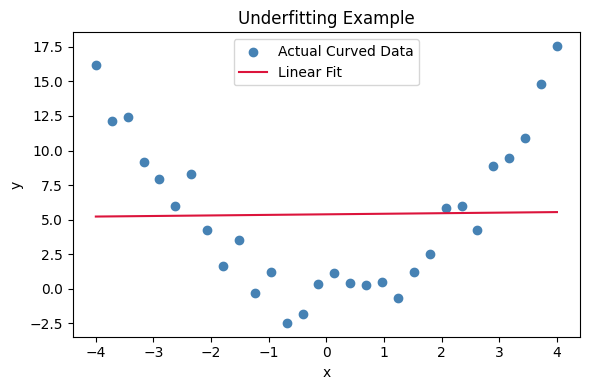

In [3]:
x2 = np.linspace(-4, 4, 30)
y2 = x2**2 + np.random.normal(0, 1.5, size=len(x2))

df_under = pd.DataFrame({"x": x2, "y": y2})

under_model = LinearRegression()
under_model.fit(df_under[["x"]], df_under["y"])
y2_hat = under_model.predict(df_under[["x"]])
mse_under = mean_squared_error(df_under["y"], y2_hat)

print("Underfitting MSE (Linear on curved data):", round(mse_under, 2))

plt.figure(figsize=(6, 4))
plt.scatter(df_under["x"], df_under["y"], color="steelblue", label="Actual Curved Data")
plt.plot(df_under["x"], y2_hat, color="crimson", label="Linear Fit")
plt.title("Underfitting Example")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.tight_layout()
plt.show()

Here the real pattern is curved, but linear regression can draw only a straight line.
That mismatch causes underfitting and raises model error.
The graph visually shows why linear fit is too simple for this data.

### Q4. How does polynomial regression improve this fit?

Linear MSE: 30.03
Polynomial (degree 2) MSE: 1.51


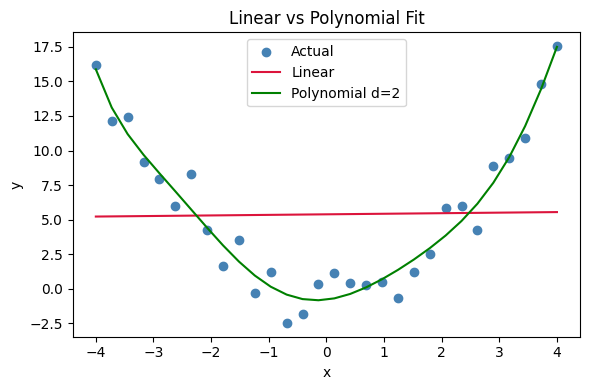

In [15]:
from sklearn.preprocessing import PolynomialFeatures

poly2 = PolynomialFeatures(degree=7, include_bias=False)
X2_poly = poly2.fit_transform(df_under[["x"]])

poly_model = LinearRegression()
poly_model.fit(X2_poly, df_under["y"])
y2_poly_hat = poly_model.predict(X2_poly)
mse_poly = mean_squared_error(df_under["y"], y2_poly_hat)

print("Linear MSE:", round(mse_under, 2))
print("Polynomial (degree 2) MSE:", round(mse_poly, 2))

order = np.argsort(df_under["x"].values)

plt.figure(figsize=(6, 4))
plt.scatter(df_under["x"], df_under["y"], color="steelblue", label="Actual")
plt.plot(df_under["x"].values[order], y2_hat[order], color="crimson", label="Linear")
plt.plot(df_under["x"].values[order], y2_poly_hat[order], color="green", label="Polynomial d=2")
plt.title("Linear vs Polynomial Fit")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.tight_layout()
plt.show()

Polynomial regression adds curved terms, so it can follow nonlinear patterns better.
We compared MSE directly: lower MSE indicates better fit on this dataset.
The green curve should track the U-shape much better than the straight red line.

## Topic 2: Logistic Regression, Sigmoid, and Classification

### Q5. Why do we use the sigmoid function in logistic regression?

[-10.          -9.89949749  -9.79899497  -9.69849246  -9.59798995
  -9.49748744  -9.39698492  -9.29648241  -9.1959799   -9.09547739
  -8.99497487  -8.89447236  -8.79396985  -8.69346734  -8.59296482
  -8.49246231  -8.3919598   -8.29145729  -8.19095477  -8.09045226
  -7.98994975  -7.88944724  -7.78894472  -7.68844221  -7.5879397
  -7.48743719  -7.38693467  -7.28643216  -7.18592965  -7.08542714
  -6.98492462  -6.88442211  -6.7839196   -6.68341709  -6.58291457
  -6.48241206  -6.38190955  -6.28140704  -6.18090452  -6.08040201
  -5.9798995   -5.87939698  -5.77889447  -5.67839196  -5.57788945
  -5.47738693  -5.37688442  -5.27638191  -5.1758794   -5.07537688
  -4.97487437  -4.87437186  -4.77386935  -4.67336683  -4.57286432
  -4.47236181  -4.3718593   -4.27135678  -4.17085427  -4.07035176
  -3.96984925  -3.86934673  -3.76884422  -3.66834171  -3.5678392
  -3.46733668  -3.36683417  -3.26633166  -3.16582915  -3.06532663
  -2.96482412  -2.86432161  -2.7638191   -2.66331658  -2.56281407
  -2.4623115

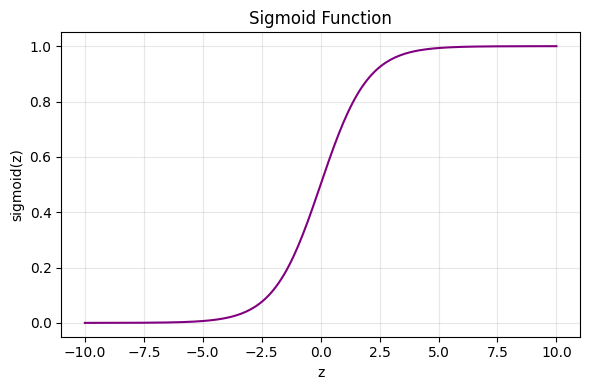

In [18]:
z = np.linspace(-10, 10, 200)  # start stop points
print(z)
sigmoid = 1 / (1 + np.exp(-z))  # sigmoid formula

plt.figure(figsize=(6, 4))  # plot size
plt.plot(z, sigmoid, color="purple")  # draw curve
plt.title("Sigmoid Function")
plt.xlabel("z")
plt.ylabel("sigmoid(z)")
plt.ylim(-0.05, 1.05)  # y limits
plt.grid(alpha=0.3)  # light grid
plt.tight_layout()
plt.show()

Sigmoid converts any real value into a probability-like value between 0 and 1.
That is why logistic regression is used for classification tasks.
The S-shaped curve is the core of probability output in logistic models.

### Q6. Why is logistic regression a classification algorithm?

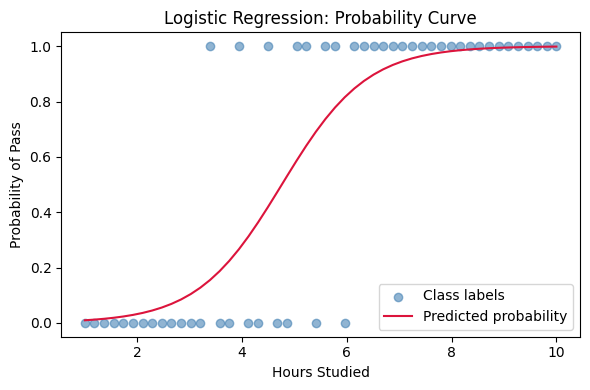

In [6]:
from sklearn.linear_model import LogisticRegression

np.random.seed(7)  # fixed randomness
hours = np.linspace(1, 10, 50)  # study range points
true_prob = 1 / (1 + np.exp(-(hours - 5)))  # true pass chance
labels = (np.random.rand(len(hours)) < true_prob).astype(int)  # random class labels

df_log = pd.DataFrame({"hours_studied": hours, "pass": labels})  # build dataframe

log_model = LogisticRegression()  # create model
log_model.fit(df_log[["hours_studied"]], df_log["pass"])  # train model
prob_hat = log_model.predict_proba(df_log[["hours_studied"]])[:, 1]  # predicted probabilities

plt.figure(figsize=(6, 4))  # plot size
plt.scatter(df_log["hours_studied"], df_log["pass"], color="steelblue", alpha=0.6, label="Class labels")  # class points
plt.plot(df_log["hours_studied"], prob_hat, color="crimson", label="Predicted probability")  # probability curve
plt.title("Logistic Regression: Probability Curve")
plt.xlabel("Hours Studied")
plt.ylabel("Probability of Pass")
plt.legend()
plt.tight_layout()
plt.show()

Logistic regression predicts probability first, then class labels from that probability.
This is why it is called a classification method, not regression for numeric targets.
The red curve shows probability smoothly increasing with study hours.

## Topic 3: Imbalance, Confusion Matrix, and Stratified Split

### Q7. Why can high accuracy still be misleading?

Accuracy: 0.8
Confusion Matrix:
[[8 0]
 [2 0]]


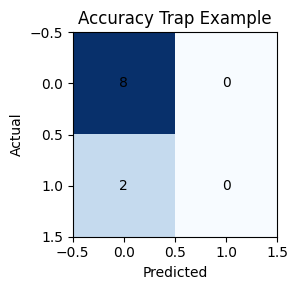

In [7]:
from sklearn.metrics import confusion_matrix, accuracy_score

y_true = np.array([0, 0, 0, 0, 0, 0, 0, 0, 1, 1])  # actual labels
y_pred_all_healthy = np.array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])  # predicts all healthy

acc = accuracy_score(y_true, y_pred_all_healthy)  # overall accuracy
cm = confusion_matrix(y_true, y_pred_all_healthy)  # error table

print("Accuracy:", round(acc, 2))
print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(4, 3))  # plot size
plt.imshow(cm, cmap="Blues")  # matrix heatmap
plt.title("Accuracy Trap Example")
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")  # cell value
plt.tight_layout()
plt.show()

This tiny dataset has 8 healthy and 2 diseased cases.
Predicting everyone as healthy gives high accuracy but misses all diseased cases.
That is why confusion matrix is important, not accuracy alone.

### Q8. Stratified Split Check 1: What changes in class ratio?

Positive ratio - Original: 0.087
Positive ratio - Test (No Stratify): 0.072
Positive ratio - Test (Stratify): 0.089


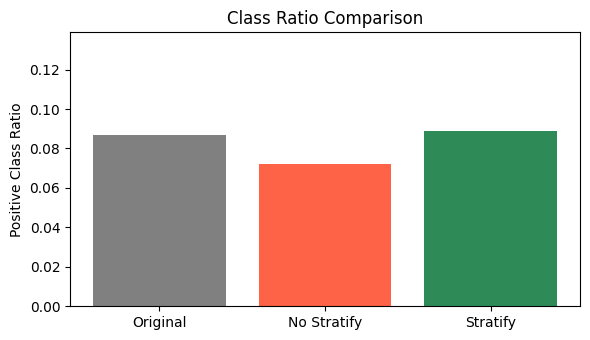

In [8]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

X_imb, y_imb = make_classification(
    n_samples=600,
    n_features=4,
    n_informative=2,
    n_redundant=0,
    weights=[0.92, 0.08],
    random_state=42
)

X_tr_ns, X_te_ns, y_tr_ns, y_te_ns = train_test_split(X_imb, y_imb, test_size=0.3, random_state=42)
X_tr_s, X_te_s, y_tr_s, y_te_s = train_test_split(X_imb, y_imb, test_size=0.3, random_state=42, stratify=y_imb)

orig_ratio = y_imb.mean()
ns_ratio = y_te_ns.mean()
s_ratio = y_te_s.mean()

print("Positive ratio - Original:", round(orig_ratio, 3))
print("Positive ratio - Test (No Stratify):", round(ns_ratio, 3))
print("Positive ratio - Test (Stratify):", round(s_ratio, 3))

plt.figure(figsize=(6, 3.5))
plt.bar(["Original", "No Stratify", "Stratify"], [orig_ratio, ns_ratio, s_ratio], color=["gray", "tomato", "seagreen"])
plt.title("Class Ratio Comparison")
plt.ylabel("Positive Class Ratio")
plt.ylim(0, max(orig_ratio, ns_ratio, s_ratio) + 0.05)
plt.tight_layout()
plt.show()

Stratified split keeps class proportions close to the original dataset.
Without stratification, minority class ratio can shift between splits.
That shift can make model evaluation less reliable.

### Q9. Stratified Split Check 2 + Confusion Matrix Terms

TN: 163 FP: 1 FN: 6 TP: 10


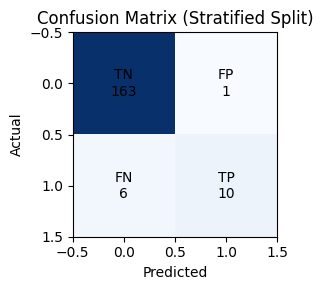

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

model_s = LogisticRegression(max_iter=300)
model_s.fit(X_tr_s, y_tr_s)
pred_s = model_s.predict(X_te_s)
cm_s = confusion_matrix(y_te_s, pred_s)

tn, fp, fn, tp = cm_s.ravel()
print("TN:", tn, "FP:", fp, "FN:", fn, "TP:", tp)

plt.figure(figsize=(4, 3))
plt.imshow(cm_s, cmap="Blues")
plt.title("Confusion Matrix (Stratified Split)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
labels = [["TN", "FP"], ["FN", "TP"]]
for i in range(2):
    for j in range(2):
        plt.text(j, i, f"{labels[i][j]}\n{cm_s[i, j]}", ha="center", va="center")
plt.tight_layout()
plt.show()

#make and train a simple model with and without the SSC

This matrix gives all four outcomes: TN, FP, FN, and TP.
In medical tasks, false negatives are often dangerous because sick cases are missed.
Using a stratified split keeps this evaluation more trustworthy.

## Topic 4: Threshold, Precision/Recall, and AUC

### Q10. What happens when threshold drops from 0.5 to 0.3?

Threshold 0.5 -> Precision: 0.91 Recall: 0.62
Threshold 0.3 -> Precision: 0.71 Recall: 0.75


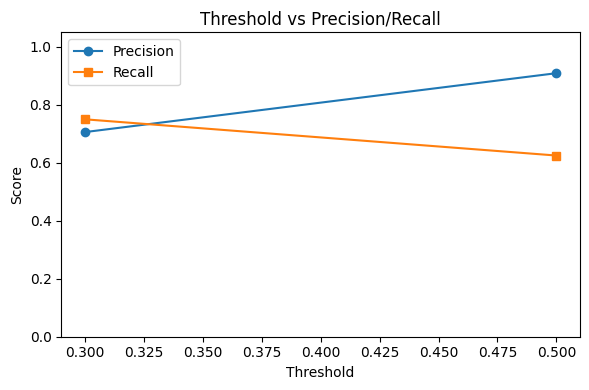

In [10]:
from sklearn.metrics import precision_score, recall_score

proba_s = model_s.predict_proba(X_te_s)[:, 1]
pred_05 = (proba_s >= 0.5).astype(int)
pred_03 = (proba_s >= 0.3).astype(int)

p05 = precision_score(y_te_s, pred_05, zero_division=0)
r05 = recall_score(y_te_s, pred_05, zero_division=0)
p03 = precision_score(y_te_s, pred_03, zero_division=0)
r03 = recall_score(y_te_s, pred_03, zero_division=0)

print("Threshold 0.5 -> Precision:", round(p05, 2), "Recall:", round(r05, 2))
print("Threshold 0.3 -> Precision:", round(p03, 2), "Recall:", round(r03, 2))

ths = [0.3, 0.5]
precisions = [p03, p05]
recalls = [r03, r05]

plt.figure(figsize=(6, 4))
plt.plot(ths, precisions, "o-", label="Precision")
plt.plot(ths, recalls, "s-", label="Recall")
plt.title("Threshold vs Precision/Recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.show()

Lower threshold usually increases recall and can reduce precision.
This is common in fraud and medical use-cases where catching positives is critical.
Business teams choose threshold based on cost of FP vs FN.

### Q11. What does AUC = 0.5 mean?

Model AUC: 0.932
Random AUC: 0.544


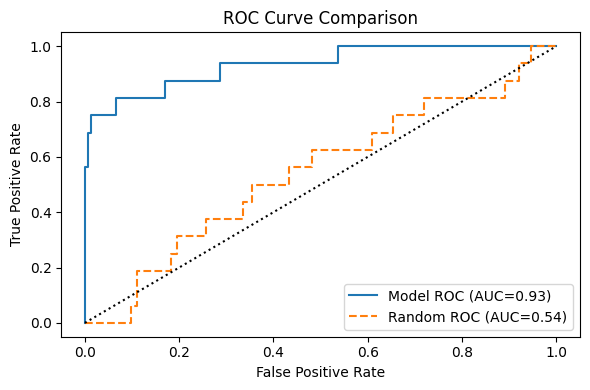

In [11]:
from sklearn.metrics import roc_curve, roc_auc_score

auc_model = roc_auc_score(y_te_s, proba_s)
random_scores = np.random.rand(len(y_te_s))
auc_random = roc_auc_score(y_te_s, random_scores)

fpr_m, tpr_m, _ = roc_curve(y_te_s, proba_s)
fpr_r, tpr_r, _ = roc_curve(y_te_s, random_scores)

print("Model AUC:", round(auc_model, 3))
print("Random AUC:", round(auc_random, 3))

plt.figure(figsize=(6, 4))
plt.plot(fpr_m, tpr_m, label=f"Model ROC (AUC={auc_model:.2f})")
plt.plot(fpr_r, tpr_r, "--", label=f"Random ROC (AUC={auc_random:.2f})")
plt.plot([0, 1], [0, 1], "k:")
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

AUC near 0.5 means the model behaves like random guessing.
Higher AUC indicates better class separation across thresholds.
ROC helps compare models even before fixing one threshold value.

## Topic 5: Missing Values with Outliers

### Q12. Why is median often better than mean for outlier-heavy data?

Original values:
[22.0, 24.0, 23.0, 25.0, 100.0, nan, 26.0, nan, 24.0]
Mean used: 34.86
Median used: 24.0


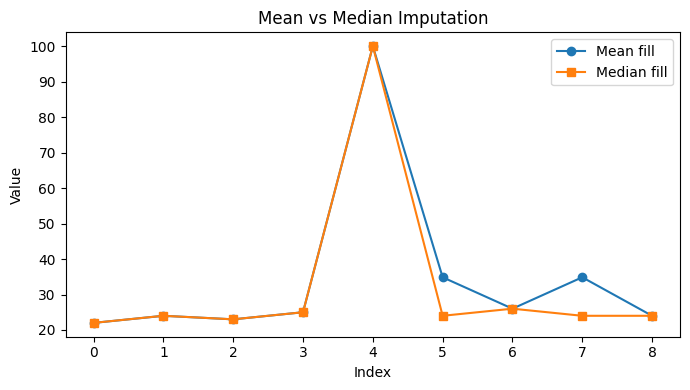

In [12]:
values = pd.Series([22, 24, 23, 25, 100, np.nan, 26, np.nan, 24])
mean_fill = values.fillna(values.mean())
median_fill = values.fillna(values.median())

print("Original values:")
print(values.tolist())
print("Mean used:", round(values.mean(), 2))
print("Median used:", round(values.median(), 2))

plt.figure(figsize=(7, 4))
plt.plot(mean_fill.values, "o-", label="Mean fill")
plt.plot(median_fill.values, "s-", label="Median fill")
plt.title("Mean vs Median Imputation")
plt.xlabel("Index")
plt.ylabel("Value")
plt.legend()
plt.tight_layout()
plt.show()

SyntaxError: invalid syntax (4079212206.py, line 1)

The outlier (100) pulls the mean upward, so mean imputation becomes less representative.
Median stays close to central behavior and is more robust to outliers.
For skewed distributions, median fill is usually safer than mean fill.

## End Summary
- Linear regression: baseline, underfitting, polynomial improvement
- Logistic regression: sigmoid-based probability classification
- Imbalanced learning: confusion matrix and stratified split are essential
- Threshold tuning and AUC improve evaluation quality
- Median imputation is safer when outliers are present